In [1]:

from pathlib import Path
import torchvision.models as tv_models
import torch.nn as nn
from fastai.vision.all import *


# 1. Diretório raiz do dataset
path = Path('./tiny-imagenet-200')
print("Diretório do dataset:", path.absolute())


Diretório do dataset: /home/mateus_a/Documents/Tinyimagenet/tiny-imagenet-200


In [2]:

# 2. Rótulo da classe (pasta avó: train/<classe_id>/images/<arquivo>.JPEG)
def get_tiny_label(file_path):
   return file_path.parent.parent.name


In [3]:
# 3. DataBlock utilizando apenas o conjunto de treino com divisão interna (ex: 15% validação)
tiny_datablock = DataBlock(
   blocks=(ImageBlock, CategoryBlock),
   get_items=get_image_files,
   splitter=RandomSplitter(valid_pct=0.15, seed=42),
   get_y=get_tiny_label,
   item_tfms=Resize(64),
   batch_tfms=aug_transforms(mult=1.0, do_flip=True, max_rotate=10.0)
)


In [4]:
# 4. Carrega apontando diretamente para a pasta 'train'
dls = tiny_datablock.dataloaders(path / 'train', bs=128, num_workers=4)


print("DataLoaders criados com sucesso!")
print(f"Total de classes: {len(dls.vocab)}")
print(f"Imagens de Treino: {len(dls.train_ds)} | Validação: {len(dls.valid_ds)}")


DataLoaders criados com sucesso!
Total de classes: 200
Imagens de Treino: 85000 | Validação: 15000


In [5]:
# 5. MobileNetV2 com pesos pré-treinados
base_model = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.DEFAULT)


# Ajuste da camada linear final para as 200 classes
num_classes = len(dls.vocab)
base_model.classifier[1] = nn.Linear(base_model.last_channel, num_classes)


<div></div>

SuggestedLRs(valley=0.0003981071640737355)

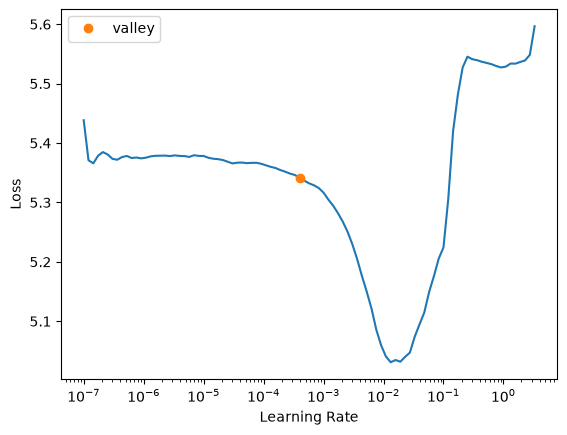

In [13]:
 learn.lr_find()

In [6]:
# 6. Criação do Learner
learn = Learner(
   dls,
   base_model,
   metrics=[accuracy, top_k_accuracy],
   loss_func=CrossEntropyLossFlat()
)


In [ ]:
# 7. Treinamento
print("Iniciando o treinamento...")
learn.fit_one_cycle(15, 1e-3)


Iniciando o treinamento...


epoch,train_loss,valid_loss,accuracy,top_k_accuracy,time
0,2.755848,2.686950,0.379000,0.654000,09:21


In [ ]:

# 8. Salvar o modelo treinado
learn.save('mobilenet_tinyimagenet_15ep')
print("Treinamento finalizado e modelo salvo!")
